# Projet : Système de Recommandation d'Images

**Auteurs** : BONNET & DURANO  
**Date** : Février 2026

---

## Objectif du projet

Construire un système de recommandation d'images qui suggère des images aux utilisateurs en fonction de leurs préférences.

### Architecture du système

1. **Collecte de données** : Téléchargement de 100+ images depuis Unsplash API
2. **Étiquetage et annotation** : Extraction de couleurs, orientation, tags
3. **Analyse de données** : Création de profils utilisateur basés sur leurs favoris
4. **Visualisation** : 6+ graphiques pour analyser les données
5. **Système de recommandation** : Filtrage basé sur le contenu (classification)
6. **Tests** : Validation de l'intégrité et de la qualité du système

---


## 📦 Configuration et Imports

Installation des bibliothèques nécessaires et imports.

In [1]:
# Installation des bibliothèques nécessaires (à exécuter une seule fois)
# !pip install python-dotenv requests pillow scikit-learn matplotlib pandas webcolors

In [1]:
# Imports standards
import os
import json
import requests
from pathlib import Path
from collections import Counter
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Data science
import numpy as np
import pandas as pd

# Image processing
from PIL import Image
from PIL.ExifTags import TAGS

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configuration
from dotenv import load_dotenv

# Charger les variables d'environnement depuis .env
load_dotenv()

print("✅ Imports terminés avec succès")

✅ Imports terminés avec succès


In [2]:
# Configuration des chemins
PROJECT_DIR = Path.cwd()
IMAGES_DIR = PROJECT_DIR / "images"
DATA_DIR = PROJECT_DIR / "data"

# Créer les dossiers s'ils n'existent pas
IMAGES_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

# Fichiers de données
METADATA_FILE = DATA_DIR / "images_metadata.json"
LABELS_FILE = DATA_DIR / "images_labels.json"
USERS_FILE = DATA_DIR / "users.json"

# Configuration Unsplash API
UNSPLASH_ACCESS_KEY = os.getenv("UNSPLASH_ACCESS_KEY")

if not UNSPLASH_ACCESS_KEY:
    raise ValueError("❌ Clé API Unsplash manquante ! Vérifiez le fichier .env")

print(f"📁 Dossier projet : {PROJECT_DIR}")
print(f"📁 Dossier images : {IMAGES_DIR}")
print(f"📁 Dossier données : {DATA_DIR}")
print(f"🔑 Clé API Unsplash : {'*' * len(UNSPLASH_ACCESS_KEY)}")

📁 Dossier projet : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1
📁 Dossier images : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1\images
📁 Dossier données : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1\data
🔑 Clé API Unsplash : *******************************************


---

## 🎯 Tâche 1 : Collecte de Données

**Objectif** : Collecter au moins 100 images sous licence ouverte avec leurs métadonnées.

**Métadonnées à extraire** :
- Nom du fichier image
- Dimensions (largeur, hauteur)
- Format du fichier
- Taille du fichier (Ko)
- URL source
- Informations de licence
- Données EXIF (si disponibles)

In [4]:
def fetch_unsplash_images(query: str = "nature", per_page: int = 30, pages: int = 4) -> List[Dict]:
    """
    Récupère des images depuis Unsplash API.
    
    Args:
        query: Terme de recherche
        per_page: Nombre d'images par page (max 30)
        pages: Nombre de pages à récupérer
    
    Returns:
        Liste de dictionnaires contenant les infos des images
    """
    base_url = "https://api.unsplash.com/search/photos"
    headers = {"Authorization": f"Client-ID {UNSPLASH_ACCESS_KEY}"}
    
    images_data = []
    
    for page in range(1, pages + 1):
        params = {
            "query": query,
            "per_page": per_page,
            "page": page
        }
        
        try:
            response = requests.get(base_url, headers=headers, params=params, timeout=10)
            response.raise_for_status()
            
            data = response.json()
            images_data.extend(data.get("results", []))
            
            print(f"✅ Page {page}/{pages} récupérée : {len(data.get('results', []))} images")
            
        except Exception as e:
            print(f"❌ Erreur page {page} : {e}")
            continue
    
    return images_data

In [5]:
def download_image(url: str, filename: str) -> bool:
    """
    Télécharge une image depuis une URL.
    
    Args:
        url: URL de l'image
        filename: Nom du fichier de destination
    
    Returns:
        True si succès, False sinon
    """
    try:
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        
        filepath = IMAGES_DIR / filename
        filepath.write_bytes(response.content)
        
        return True
    except Exception as e:
        print(f"❌ Erreur téléchargement {filename} : {e}")
        return False

In [6]:
def extract_exif_data(image_path: Path) -> Dict:
    """
    Extrait les données EXIF d'une image.

    Note : L'API Unsplash renvoie des JPEG recompressés sans bloc EXIF embarqué.
    Dans ce cas, _getexif() retourne None et la fonction renvoie un dict vide {}.
    Ce comportement est attendu et conforme à la consigne "si disponibles".

    Args:
        image_path: Chemin vers l'image

    Returns:
        Dictionnaire contenant les données EXIF (vide si absent)
    """
    exif_data = {}

    try:
        img = Image.open(image_path)
        exif = img._getexif()

        if exif:
            for tag_id, value in exif.items():
                tag = TAGS.get(tag_id, tag_id)
                exif_data[tag] = str(value)
    except:
        pass

    return exif_data


In [7]:
def collect_images_metadata(queries: List[str] = ["nature", "architecture", "food", "animals"], 
                           per_query: int = 30) -> Dict:
    """
    Collecte des images et leurs métadonnées depuis Unsplash.
    
    Args:
        queries: Liste de termes de recherche
        per_query: Nombre d'images par requête
    
    Returns:
        Dictionnaire contenant toutes les métadonnées
    """
    all_metadata = {}
    image_counter = 1
    
    for query in queries:
        print(f"\n🔍 Recherche : '{query}'")
        images_data = fetch_unsplash_images(query, per_page=per_query, pages=1)
        
        for img_data in images_data:
            filename = f"image_{image_counter:03d}.jpg"
            image_url = img_data["urls"]["regular"]
            
            # Télécharger l'image
            if download_image(image_url, filename):
                image_path = IMAGES_DIR / filename
                
                # Ouvrir l'image pour extraire les infos
                try:
                    with Image.open(image_path) as img:
                        width, height = img.size
                        format_img = img.format
                except:
                    print(f"⚠️ Impossible d'ouvrir {filename}")
                    continue
                
                # Taille du fichier en Ko
                file_size_kb = image_path.stat().st_size / 1024
                
                # Extraire données EXIF
                exif_data = extract_exif_data(image_path)
                
                # Stocker les métadonnées
                all_metadata[filename] = {
                    "filename": filename,
                    "width": width,
                    "height": height,
                    "format": format_img,
                    "file_size_kb": round(file_size_kb, 2),
                    "source_url": img_data["links"]["html"],
                    "download_url": image_url,
                    "license": "Unsplash License",
                    "author": img_data["user"]["name"],
                    "author_url": img_data["user"]["links"]["html"],
                    "description": img_data.get("description", ""),
                    "alt_description": img_data.get("alt_description", ""),
                    "query": query,
                    "exif": exif_data
                }
                
                print(f"✅ {filename} : {width}x{height}, {file_size_kb:.1f} Ko")
                image_counter += 1
    
    return all_metadata

In [8]:
# Collecte des images (peut prendre quelques minutes)
print("🚀 Début de la collecte d'images...\n")

# Diversifier les requêtes pour avoir une collection variée
search_queries = ["nature", "architecture", "food", "animals", "technology", "art"]

metadata = collect_images_metadata(queries=search_queries, per_query=20)

print(f"\n✅ Collecte terminée : {len(metadata)} images téléchargées")

🚀 Début de la collecte d'images...


🔍 Recherche : 'nature'


✅ Page 1/1 récupérée : 20 images
✅ image_001.jpg : 1080x715, 112.0 Ko
✅ image_002.jpg : 1080x643, 136.7 Ko
✅ image_003.jpg : 1080x1620, 661.1 Ko
✅ image_004.jpg : 1080x1783, 426.2 Ko
✅ image_005.jpg : 1080x1620, 631.6 Ko
✅ image_006.jpg : 1080x1620, 222.2 Ko
✅ image_007.jpg : 1080x717, 108.7 Ko
✅ image_008.jpg : 1080x720, 237.3 Ko
✅ image_009.jpg : 1080x1620, 307.8 Ko
✅ image_010.jpg : 1080x1618, 852.9 Ko
✅ image_011.jpg : 1080x1922, 350.1 Ko
✅ image_012.jpg : 1080x720, 100.7 Ko
✅ image_013.jpg : 1080x720, 180.3 Ko
✅ image_014.jpg : 1080x643, 169.0 Ko
✅ image_015.jpg : 1080x1620, 212.8 Ko
✅ image_016.jpg : 1080x721, 137.0 Ko
✅ image_017.jpg : 1080x675, 168.3 Ko
✅ image_018.jpg : 1080x720, 215.4 Ko
✅ image_019.jpg : 1080x717, 140.7 Ko
✅ image_020.jpg : 1080x719, 241.8 Ko

🔍 Recherche : 'architecture'
✅ Page 1/1 récupérée : 20 images
✅ image_021.jpg : 1080x720, 99.0 Ko
✅ image_022.jpg : 1080x720, 100.7 Ko
✅ image_023.jpg : 1080x720, 136.7 Ko
✅ image_024.jpg : 1080x1350, 203.9 Ko
✅ image_

In [9]:
# Sauvegarder les métadonnées
with open(METADATA_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"💾 Métadonnées sauvegardées : {METADATA_FILE}")
print(f"📊 Nombre total d'images : {len(metadata)}")

💾 Métadonnées sauvegardées : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1\data\images_metadata.json
📊 Nombre total d'images : 120


In [10]:
# Afficher quelques statistiques rapides
df_meta = pd.DataFrame(metadata).T

print("\n📈 Statistiques de la collection :")
print(f"  - Taille moyenne : {df_meta['file_size_kb'].mean():.2f} Ko")
print(f"  - Largeur moyenne : {df_meta['width'].mean():.0f} px")
print(f"  - Hauteur moyenne : {df_meta['height'].mean():.0f} px")
print(f"\n  - Formats : {df_meta['format'].value_counts().to_dict()}")
print(f"\n  - Requêtes : {df_meta['query'].value_counts().to_dict()}")


📈 Statistiques de la collection :
  - Taille moyenne : 212.21 Ko
  - Largeur moyenne : 1080 px
  - Hauteur moyenne : 1074 px

  - Formats : {'JPEG': 120}

  - Requêtes : {'nature': 20, 'architecture': 20, 'food': 20, 'animals': 20, 'technology': 20, 'art': 20}


---

## 🏷️ Tâche 2 : Étiquetage et Annotation

**Objectif** : Ajouter des étiquettes descriptives et des caractéristiques calculées.

**Caractéristiques à extraire** :
- Couleurs prédominantes (3-5 couleurs via KMeans)
- Orientation (paysage, portrait, carré)
- Catégorie de taille (vignette, moyenne, grande)
- Tags descriptifs (automatisés depuis Unsplash)

In [11]:
def rgb_to_name(rgb: Tuple[int, int, int]) -> str:
    """
    Convertit une couleur RGB en nom approximatif.

    Args:
        rgb: Tuple (R, G, B)

    Returns:
        Nom de couleur approximatif
    """
    r, g, b = rgb

    # Couleurs de base simplifiées
    if r > 200 and g < 100 and b < 100:
        return "rouge"
    elif r < 100 and g > 200 and b < 100:
        return "vert"
    elif r < 100 and g < 100 and b > 200:
        return "bleu"
    elif r > 200 and g > 200 and b < 100:
        return "jaune"
    elif r > 200 and g < 150 and b > 200:
        return "magenta"
    elif r < 150 and g > 200 and b > 200:
        return "cyan"
    elif r > 220 and g > 220 and b > 220:
        return "blanc"
    elif r < 50 and g < 50 and b < 50:
        return "noir"
    elif abs(r - g) < 20 and abs(g - b) < 20:
        return "gris"
    elif r > 200 and g > 150 and b < 100:
        return "orange"
    elif r > 150 and g > 100 and b < 80:
        return "marron"
    elif r > 200 and g > 150 and b > 200:
        return "rose"
    else:
        # Dominante : distinguer rouge vif des tons bruns/kaki/ocre
        # (évite le sur-classement des couleurs chaudes neutres en "rouge")
        if r > g and r > b:
            if r > 140 and g > 75 and b < 100:
                return "marron"  # tons bruns, kaki, ocre, sable
            return "rouge"
        elif g > r and g > b:
            return "vert"
        else:
            return "bleu"


In [28]:
def extract_dominant_colors(image_path: Path, n_colors: int = 5) -> List[List[int]]:
    """
    Extrait les couleurs dominantes d'une image avec KMeans.
    
    Args:
        image_path: Chemin vers l'image
        n_colors: Nombre de couleurs à extraire
    
    Returns:
        Liste de couleurs RGB
    """
    try:
        # Charger et redimensionner l'image (pour accélérer)
        img = Image.open(image_path)
        img.thumbnail((200, 200))
        
        # Convertir en tableau numpy
        img_array = np.array(img)
        
        # Si grayscale, convertir en RGB
        if len(img_array.shape) == 2:
            img_array = np.stack([img_array] * 3, axis=-1)
        elif img_array.shape[2] == 4:  # RGBA
            img_array = img_array[:, :, :3]
        
        # Reshape pour KMeans
        pixels = img_array.reshape(-1, 3)
        
        # Appliquer KMeans
        kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init=10)
        kmeans.fit(pixels)
        
        # Récupérer les centres (couleurs dominantes)
        colors = kmeans.cluster_centers_.astype(int).tolist()
        
        return colors
    
    except Exception as e:
        print(f"❌ Erreur extraction couleurs {image_path.name} : {e}")
        return [[128, 128, 128]]  # Gris par défaut

In [13]:
def get_orientation(width: int, height: int) -> str:
    """
    Détermine l'orientation d'une image.
    
    Args:
        width: Largeur de l'image
        height: Hauteur de l'image
    
    Returns:
        'paysage', 'portrait' ou 'carré'
    """
    ratio = width / height
    
    if 0.95 <= ratio <= 1.05:
        return "carré"
    elif ratio > 1.05:
        return "paysage"
    else:
        return "portrait"

In [14]:
def get_size_category(width: int, height: int) -> str:
    """
    Détermine la catégorie de taille d'une image.
    
    Args:
        width: Largeur de l'image
        height: Hauteur de l'image
    
    Returns:
        'vignette', 'moyenne' ou 'grande'
    """
    max_dimension = max(width, height)
    
    if max_dimension < 500:
        return "vignette"
    elif max_dimension <= 1500:
        return "moyenne"
    else:
        return "grande"

In [15]:
def create_labels():
    """
    Crée les labels pour toutes les images.
    
    Returns:
        Dictionnaire contenant tous les labels
    """
    # Charger les métadonnées
    with open(METADATA_FILE, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    
    labels = {}
    
    for filename, meta in metadata.items():
        print(f"🏷️ Étiquetage : {filename}")
        
        image_path = IMAGES_DIR / filename
        
        # Extraire couleurs dominantes
        dominant_colors = extract_dominant_colors(image_path, n_colors=5)
        
        # Convertir RGB en noms
        color_names = [rgb_to_name(tuple(color)) for color in dominant_colors]
        
        # Orientation
        orientation = get_orientation(meta["width"], meta["height"])
        
        # Catégorie de taille
        size_category = get_size_category(meta["width"], meta["height"])
        
        # Tags (depuis la description/query)
        tags = [meta["query"]]
        if meta.get("alt_description"):
            # Extraire quelques mots-clés de la description
            words = meta["alt_description"].lower().split()
            tags.extend([w for w in words if len(w) > 3][:5])
        
        # Stocker les labels
        labels[filename] = {
            "predominant_colors": dominant_colors,
            "color_names": color_names,
            "orientation": orientation,
            "size_category": size_category,
            "tags": list(set(tags))  # Enlever les doublons
        }
    
    return labels

In [16]:
# Créer les labels (peut prendre quelques minutes)
print("🚀 Début de l'étiquetage...\n")

labels = create_labels()

print(f"\n✅ Étiquetage terminé : {len(labels)} images annotées")

🚀 Début de l'étiquetage...

🏷️ Étiquetage : image_001.jpg
🏷️ Étiquetage : image_002.jpg
🏷️ Étiquetage : image_003.jpg
🏷️ Étiquetage : image_004.jpg
🏷️ Étiquetage : image_005.jpg
🏷️ Étiquetage : image_006.jpg
🏷️ Étiquetage : image_007.jpg
🏷️ Étiquetage : image_008.jpg
🏷️ Étiquetage : image_009.jpg
🏷️ Étiquetage : image_010.jpg
🏷️ Étiquetage : image_011.jpg
🏷️ Étiquetage : image_012.jpg
🏷️ Étiquetage : image_013.jpg
🏷️ Étiquetage : image_014.jpg
🏷️ Étiquetage : image_015.jpg
🏷️ Étiquetage : image_016.jpg
🏷️ Étiquetage : image_017.jpg
🏷️ Étiquetage : image_018.jpg
🏷️ Étiquetage : image_019.jpg
🏷️ Étiquetage : image_020.jpg
🏷️ Étiquetage : image_021.jpg
🏷️ Étiquetage : image_022.jpg
🏷️ Étiquetage : image_023.jpg
🏷️ Étiquetage : image_024.jpg
🏷️ Étiquetage : image_025.jpg
🏷️ Étiquetage : image_026.jpg
🏷️ Étiquetage : image_027.jpg
🏷️ Étiquetage : image_028.jpg
🏷️ Étiquetage : image_029.jpg
🏷️ Étiquetage : image_030.jpg
🏷️ Étiquetage : image_031.jpg
🏷️ Étiquetage : image_032.jpg
🏷️ Étiquetag

In [17]:
# Sauvegarder les labels
with open(LABELS_FILE, "w", encoding="utf-8") as f:
    json.dump(labels, f, ensure_ascii=False, indent=2)

print(f"💾 Labels sauvegardés : {LABELS_FILE}")

💾 Labels sauvegardés : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1\data\images_labels.json


In [18]:
# Afficher un exemple
example_filename = list(labels.keys())[0]
print(f"\n📋 Exemple de labels pour {example_filename} :")
print(json.dumps(labels[example_filename], indent=2, ensure_ascii=False))


📋 Exemple de labels pour image_001.jpg :
{
  "predominant_colors": [
    [
      245,
      243,
      239
    ],
    [
      180,
      144,
      62
    ],
    [
      221,
      206,
      180
    ],
    [
      203,
      164,
      100
    ],
    [
      142,
      114,
      27
    ]
  ],
  "color_names": [
    "blanc",
    "marron",
    "rouge",
    "rouge",
    "marron"
  ],
  "orientation": "paysage",
  "size_category": "moyenne",
  "tags": [
    "nature",
    "flowers",
    "orange"
  ]
}


---

## 👥 Tâche 3 : Analyse de Données

**Objectif** : Construire des profils de préférences utilisateur basés sur leurs sélections.

**Profil utilisateur** :
- Couleurs favorites
- Orientation favorite
- Taille favorite
- Tags favoris

In [19]:
def create_simulated_users(n_users: int = 5, min_favorites: int = 10, max_favorites: int = 20) -> Dict:
    """
    Crée des utilisateurs simulés avec des préférences différentes.
    
    Args:
        n_users: Nombre d'utilisateurs à créer
        min_favorites: Nombre minimum de favoris par utilisateur
        max_favorites: Nombre maximum de favoris par utilisateur
    
    Returns:
        Dictionnaire contenant les profils utilisateurs
    """
    # Charger les labels
    with open(LABELS_FILE, "r", encoding="utf-8") as f:
        labels = json.load(f)
    
    all_images = list(labels.keys())
    
    # Profils prédéfinis pour diversité
    user_preferences = [
        {"name": "Amoureux de la nature", "preferred_tags": ["nature", "animals"], "preferred_colors": ["vert", "bleu"]},
        {"name": "Fan d'architecture", "preferred_tags": ["architecture", "technology"], "preferred_colors": ["gris", "blanc", "noir"]},
        {"name": "Foodie", "preferred_tags": ["food"], "preferred_colors": ["rouge", "orange", "jaune"]},
        {"name": "Artiste", "preferred_tags": ["art"], "preferred_colors": ["magenta", "cyan", "rose"]},
        {"name": "Éclectique", "preferred_tags": [], "preferred_colors": []},
    ]
    
    users = {}
    
    for i in range(n_users):
        user_id = f"user_{i+1:03d}"
        prefs = user_preferences[i % len(user_preferences)]
        
        # Sélectionner des favoris selon les préférences
        if prefs["preferred_tags"]:
            # Filtrer par tags préférés
            matching_images = [
                img for img in all_images
                if any(tag in labels[img]["tags"] for tag in prefs["preferred_tags"])
            ]
            
            if matching_images:
                n_favs = min(len(matching_images), np.random.randint(min_favorites, max_favorites + 1))
                favorites = np.random.choice(matching_images, n_favs, replace=False).tolist()
            else:
                n_favs = np.random.randint(min_favorites, max_favorites + 1)
                favorites = np.random.choice(all_images, n_favs, replace=False).tolist()
        else:
            # Sélection aléatoire
            n_favs = np.random.randint(min_favorites, max_favorites + 1)
            favorites = np.random.choice(all_images, n_favs, replace=False).tolist()
        
        users[user_id] = {
            "user_id": user_id,
            "name": prefs["name"],
            "favorite_images": favorites
        }
    
    return users

In [20]:
def build_user_profile(user_data: Dict, labels: Dict) -> Dict:
    """
    Construit le profil d'un utilisateur à partir de ses favoris.
    
    Args:
        user_data: Données de l'utilisateur (avec favorite_images)
        labels: Dictionnaire de tous les labels
    
    Returns:
        Profil complet de l'utilisateur
    """
    favorites = user_data["favorite_images"]
    
    # Collecter toutes les couleurs
    all_colors = []
    for img in favorites:
        all_colors.extend(labels[img]["color_names"])
    
    # Collecter toutes les orientations
    all_orientations = [labels[img]["orientation"] for img in favorites]
    
    # Collecter toutes les tailles
    all_sizes = [labels[img]["size_category"] for img in favorites]
    
    # Collecter tous les tags
    all_tags = []
    for img in favorites:
        all_tags.extend(labels[img]["tags"])
    
    # Trouver les plus fréquents
    favorite_colors = [color for color, _ in Counter(all_colors).most_common(3)]
    favorite_orientation = Counter(all_orientations).most_common(1)[0][0]
    favorite_size = Counter(all_sizes).most_common(1)[0][0]
    favorite_tags = [tag for tag, _ in Counter(all_tags).most_common(5)]
    
    return {
        "user_id": user_data["user_id"],
        "name": user_data["name"],
        "favorite_colors": favorite_colors,
        "favorite_orientation": favorite_orientation,
        "favorite_size": favorite_size,
        "favorite_tags": favorite_tags,
        "favorite_images": favorites
    }

In [21]:
# Créer les utilisateurs simulés
print("👥 Création des utilisateurs simulés...\n")

users_raw = create_simulated_users(n_users=5, min_favorites=10, max_favorites=20)

print(f"✅ {len(users_raw)} utilisateurs créés")

👥 Création des utilisateurs simulés...

✅ 5 utilisateurs créés


In [22]:
# Charger les labels
with open(LABELS_FILE, "r", encoding="utf-8") as f:
    labels = json.load(f)

# Construire les profils
print("\n🔨 Construction des profils utilisateurs...\n")

users = {}
for user_id, user_data in users_raw.items():
    profile = build_user_profile(user_data, labels)
    users[user_id] = profile
    
    print(f"✅ {user_id} ({profile['name']}) :")
    print(f"   - Couleurs : {profile['favorite_colors']}")
    print(f"   - Orientation : {profile['favorite_orientation']}")
    print(f"   - Tags : {profile['favorite_tags']}")
    print()


🔨 Construction des profils utilisateurs...

✅ user_001 (Amoureux de la nature) :
   - Couleurs : ['vert', 'rouge', 'gris']
   - Orientation : paysage
   - Tags : ['nature', 'animals', 'daytime', 'brown', 'trees']

✅ user_002 (Fan d'architecture) :
   - Couleurs : ['gris', 'bleu', 'noir']
   - Orientation : paysage
   - Tags : ['technology', 'architecture', 'building', 'blue', 'gray']

✅ user_003 (Foodie) :
   - Couleurs : ['rouge', 'gris', 'marron']
   - Orientation : portrait
   - Tags : ['food', 'bowl', 'cooked', 'vegetable', 'black']

✅ user_004 (Artiste) :
   - Couleurs : ['rouge', 'gris', 'bleu']
   - Orientation : paysage
   - Tags : ['art', 'painting', 'blue', 'abstract', 'brown']

✅ user_005 (Éclectique) :
   - Couleurs : ['gris', 'rouge', 'bleu']
   - Orientation : paysage
   - Tags : ['nature', 'architecture', 'art', 'painting', 'technology']



In [23]:
# Sauvegarder les profils utilisateurs
with open(USERS_FILE, "w", encoding="utf-8") as f:
    json.dump(users, f, ensure_ascii=False, indent=2)

print(f"💾 Profils utilisateurs sauvegardés : {USERS_FILE}")

💾 Profils utilisateurs sauvegardés : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1\data\users.json


In [24]:
# Analyse des tendances globales
print("\n📊 Tendances globales :")

# Couleurs les plus populaires
all_user_colors = []
for user in users.values():
    all_user_colors.extend(user["favorite_colors"])

color_counts = Counter(all_user_colors)
print(f"\n🎨 Couleurs les plus populaires :")
for color, count in color_counts.most_common(5):
    print(f"   - {color} : {count} mentions")

# Tags les plus populaires
all_user_tags = []
for user in users.values():
    all_user_tags.extend(user["favorite_tags"])

tag_counts = Counter(all_user_tags)
print(f"\n🏷️ Tags les plus populaires :")
for tag, count in tag_counts.most_common(5):
    print(f"   - {tag} : {count} mentions")


📊 Tendances globales :

🎨 Couleurs les plus populaires :
   - gris : 5 mentions
   - rouge : 4 mentions
   - bleu : 3 mentions
   - vert : 1 mentions
   - noir : 1 mentions

🏷️ Tags les plus populaires :
   - nature : 2 mentions
   - brown : 2 mentions
   - technology : 2 mentions
   - architecture : 2 mentions
   - blue : 2 mentions


---

## 📊 Tâche 4 : Visualisation des Données

**Objectif** : Créer au moins 6 visualisations révélant des insights.

**Visualisations requises** :
1. Nombre d'images par orientation
2. Nombre d'images par catégorie de taille
3. Distribution des formats d'image
4. Couleurs prédominantes (palettes)
5. Histogramme des fréquences de couleurs
6. Tags les plus courants

In [3]:
# Charger toutes les données
with open(METADATA_FILE, "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(LABELS_FILE, "r", encoding="utf-8") as f:
    labels = json.load(f)

with open(USERS_FILE, "r", encoding="utf-8") as f:
    users = json.load(f)

# Convertir en DataFrames
df_meta = pd.DataFrame(metadata).T
df_labels = pd.DataFrame(labels).T

print("✅ Données chargées pour visualisation")

✅ Données chargées pour visualisation


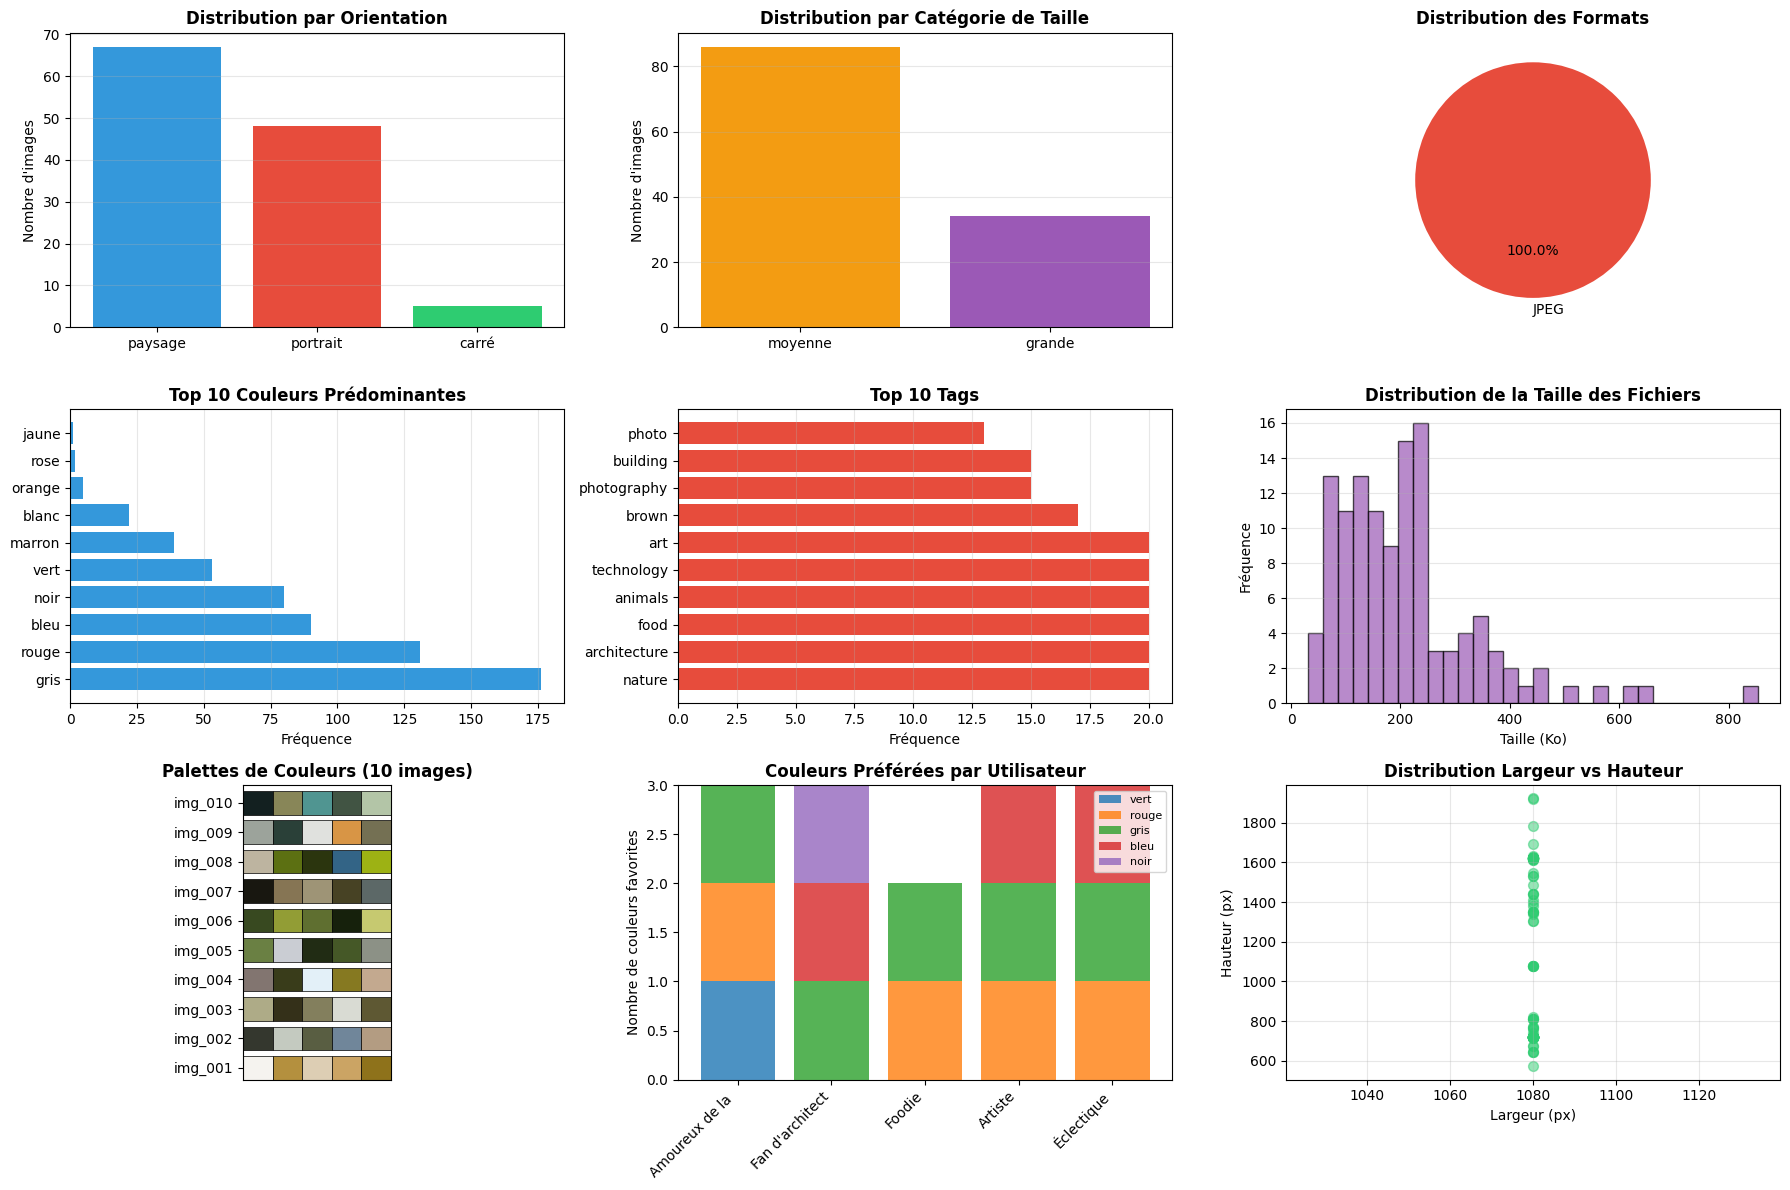


💾 Visualisations sauvegardées : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1\data\visualisations.png


In [26]:
# Configuration générale pour les graphiques
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Créer une figure avec plusieurs sous-graphiques
fig = plt.figure(figsize=(18, 12))

# 1. Nombre d'images par orientation
ax1 = plt.subplot(3, 3, 1)
orientation_counts = df_labels['orientation'].value_counts()
ax1.bar(orientation_counts.index, orientation_counts.values, color=['#3498db', '#e74c3c', '#2ecc71'])
ax1.set_title('Distribution par Orientation', fontsize=12, fontweight='bold')
ax1.set_ylabel('Nombre d\'images')
ax1.grid(axis='y', alpha=0.3)

# 2. Nombre d'images par catégorie de taille
ax2 = plt.subplot(3, 3, 2)
size_counts = df_labels['size_category'].value_counts()
ax2.bar(size_counts.index, size_counts.values, color=['#f39c12', '#9b59b6', '#1abc9c'])
ax2.set_title('Distribution par Catégorie de Taille', fontsize=12, fontweight='bold')
ax2.set_ylabel('Nombre d\'images')
ax2.grid(axis='y', alpha=0.3)

# 3. Distribution des formats d'image
ax3 = plt.subplot(3, 3, 3)
format_counts = df_meta['format'].value_counts()
colors_pie = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
ax3.pie(format_counts.values, labels=format_counts.index, autopct='%1.1f%%', 
        colors=colors_pie[:len(format_counts)], startangle=90)
ax3.set_title('Distribution des Formats', fontsize=12, fontweight='bold')

# 4. Histogramme des fréquences de couleurs
ax4 = plt.subplot(3, 3, 4)
all_colors = []
for colors_list in df_labels['color_names']:
    all_colors.extend(colors_list)
color_freq = Counter(all_colors)
top_colors = color_freq.most_common(10)
ax4.barh([c[0] for c in top_colors], [c[1] for c in top_colors], color='#3498db')
ax4.set_title('Top 10 Couleurs Prédominantes', fontsize=12, fontweight='bold')
ax4.set_xlabel('Fréquence')
ax4.grid(axis='x', alpha=0.3)

# 5. Tags les plus courants
ax5 = plt.subplot(3, 3, 5)
all_tags = []
for tags_list in df_labels['tags']:
    all_tags.extend(tags_list)
tag_freq = Counter(all_tags)
top_tags = tag_freq.most_common(10)
ax5.barh([t[0] for t in top_tags], [t[1] for t in top_tags], color='#e74c3c')
ax5.set_title('Top 10 Tags', fontsize=12, fontweight='bold')
ax5.set_xlabel('Fréquence')
ax5.grid(axis='x', alpha=0.3)

# 6. Distribution de la taille des fichiers
ax6 = plt.subplot(3, 3, 6)
ax6.hist(df_meta['file_size_kb'], bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
ax6.set_title('Distribution de la Taille des Fichiers', fontsize=12, fontweight='bold')
ax6.set_xlabel('Taille (Ko)')
ax6.set_ylabel('Fréquence')
ax6.grid(axis='y', alpha=0.3)

# 7. Palettes de couleurs prédominantes (échantillon)
ax7 = plt.subplot(3, 3, 7)
sample_images = list(labels.keys())[:10]
y_pos = 0
for img in sample_images:
    colors = labels[img]['predominant_colors']
    for i, color in enumerate(colors[:5]):
        rect = patches.Rectangle((i, y_pos), 1, 0.8, 
                                 facecolor=np.array(color)/255, edgecolor='black', linewidth=0.5)
        ax7.add_patch(rect)
    y_pos += 1

ax7.set_xlim(0, 5)
ax7.set_ylim(0, len(sample_images))
ax7.set_aspect('equal')
ax7.set_title('Palettes de Couleurs (10 images)', fontsize=12, fontweight='bold')
ax7.set_yticks(np.arange(len(sample_images)) + 0.4)
ax7.set_yticklabels([img.replace('image_', 'img_').replace('.jpg', '') for img in sample_images])
ax7.set_xticks([])

# 8. Couleurs préférées par utilisateur
ax8 = plt.subplot(3, 3, 8)
user_names = []
user_color_counts = {}

for user in users.values():
    user_names.append(user['name'][:15])  # Limiter la longueur
    for color in user['favorite_colors']:
        if color not in user_color_counts:
            user_color_counts[color] = []
        user_color_counts[color].append(user['name'][:15])

# Créer un graphique empilé
bottom = np.zeros(len(user_names))
colors_to_plot = list(user_color_counts.keys())[:5]

for color in colors_to_plot:
    values = [user_color_counts[color].count(name) for name in user_names]
    ax8.bar(user_names, values, bottom=bottom, label=color, alpha=0.8)
    bottom += values

ax8.set_title('Couleurs Préférées par Utilisateur', fontsize=12, fontweight='bold')
ax8.set_ylabel('Nombre de couleurs favorites')
ax8.legend(loc='upper right', fontsize=8)
ax8.tick_params(axis='x', rotation=45)
plt.setp(ax8.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 9. Comparaison dimensions (largeur vs hauteur)
ax9 = plt.subplot(3, 3, 9)
ax9.scatter(df_meta['width'], df_meta['height'], alpha=0.5, c='#2ecc71', s=50)
ax9.set_title('Distribution Largeur vs Hauteur', fontsize=12, fontweight='bold')
ax9.set_xlabel('Largeur (px)')
ax9.set_ylabel('Hauteur (px)')
ax9.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'visualisations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💾 Visualisations sauvegardées : {DATA_DIR / 'visualisations.png'}")

---

## 🤖 Tâche 5 : Système de Recommandation

**Objectif** : Implémenter un système qui recommande des images aux utilisateurs.

**Approche choisie** : Filtrage basé sur le contenu (classification)

**Méthode** :
1. Encoder les caractéristiques des images (couleurs, orientation, taille, tags)
2. Entraîner un classifieur sur les favoris de l'utilisateur (Favori / Non Favori)
3. Prédire quelles images non vues l'utilisateur aimerait
4. Retourner les top N recommandations avec justification

In [15]:
def prepare_features(labels: Dict, metadata: Dict) -> pd.DataFrame:
    """
    Prépare les caractéristiques pour l'apprentissage automatique.
    Amélioration : On récupère toutes les couleurs et tous les tags sous forme de liste.
    """
    features = []
    
    for filename in labels.keys():
        label_data = labels[filename]
        meta_data = metadata[filename]
        
        feature_dict = {
            'filename': filename,
            'orientation': label_data['orientation'],
            'size_category': label_data['size_category'],
            'width': meta_data['width'],
            'height': meta_data['height'],
            'file_size_kb': meta_data['file_size_kb'],
            'aspect_ratio': meta_data['width'] / meta_data['height'],
            # Au lieu de 'color_1', on prend la liste complète
            'all_colors': label_data['color_names'],
            # Au lieu du 'primary_tag', on prend la liste complète
            'all_tags': label_data['tags']
        }
        
        features.append(feature_dict)
    
    return pd.DataFrame(features)

In [16]:
# Préparer les features
print("🔧 Préparation des caractéristiques...\n")

df_features = prepare_features(labels, metadata)

print(f"✅ {len(df_features)} images avec caractéristiques")
print(f"\n📋 Colonnes : {df_features.columns.tolist()}")
print(f"\n📊 Aperçu :")
print(df_features.head())

🔧 Préparation des caractéristiques...

✅ 120 images avec caractéristiques

📋 Colonnes : ['filename', 'orientation', 'size_category', 'width', 'height', 'file_size_kb', 'aspect_ratio', 'all_colors', 'all_tags']

📊 Aperçu :
        filename orientation size_category  width  height  file_size_kb  \
0  image_001.jpg     paysage       moyenne   1080     715        112.01   
1  image_002.jpg     paysage       moyenne   1080     643        136.68   
2  image_003.jpg    portrait        grande   1080    1620        661.09   
3  image_004.jpg    portrait        grande   1080    1783        426.23   
4  image_005.jpg    portrait        grande   1080    1620        631.56   

   aspect_ratio                             all_colors  \
0      1.510490  [blanc, marron, rouge, rouge, marron]   
1      1.679627        [gris, gris, vert, bleu, rouge]   
2      0.666667     [rouge, rouge, rouge, gris, rouge]   
3      0.605721      [gris, vert, blanc, rouge, rouge]   
4      0.666667         [vert, gris, 

In [17]:
from sklearn.preprocessing import MultiLabelBinarizer

def encode_features(df: pd.DataFrame) -> Tuple[np.ndarray, Dict]:
    """
    Encode les caractéristiques.
    Utilisation de variables binaires indépendantes pour chaque tag et chaque couleur.
    """
    df_encoded = df.copy()
    
    # 1. Variables catégorielles simples (orientation etc.)
    categorical_cols = ['orientation', 'size_category']
    df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols)
    
    # 2. Encodage des listes de couleurs via MultiLabelBinarizer
    mlb_colors = MultiLabelBinarizer()
    colors_bin = mlb_colors.fit_transform(df_encoded['all_colors'])
    colors_df = pd.DataFrame(colors_bin, columns=[f"color_{c}" for c in mlb_colors.classes_])
    
    # 3. Encodage des listes de tags via MultiLabelBinarizer
    mlb_tags = MultiLabelBinarizer()
    tags_bin = mlb_tags.fit_transform(df_encoded['all_tags'])
    tags_df = pd.DataFrame(tags_bin, columns=[f"tag_{t}" for t in mlb_tags.classes_])
    
    # On supprime les anciennes colonnes de listes
    df_encoded = df_encoded.drop(columns=['all_colors', 'all_tags'])
    
    # On s'assure que les index sont bien alignés avant la concaténation
    df_encoded.reset_index(drop=True, inplace=True)
    colors_df.reset_index(drop=True, inplace=True)
    tags_df.reset_index(drop=True, inplace=True)
    
    # On rassemble tout dans un seul DataFrame complet
    df_final = pd.concat([df_encoded, colors_df, tags_df], axis=1)
    
    # On sélectionne les colonnes numériques (en omettant juste le nom du fichier)
    feature_cols = [c for c in df_final.columns if c != 'filename']
    
    for col in feature_cols:
        df_final[col] = df_final[col].astype(float)
        
    X = df_final[feature_cols].values
    
    return X, {'colors': mlb_colors, 'tags': mlb_tags}, feature_cols

In [18]:
# Encoder les features
X_all, encoders, feature_cols = encode_features(df_features)

print(f"✅ Caractéristiques encodées : {X_all.shape}")
print(f"📋 Features utilisées : {feature_cols}")

✅ Caractéristiques encodées : (120, 251)
📋 Features utilisées : ['width', 'height', 'file_size_kb', 'aspect_ratio', 'orientation_carré', 'orientation_paysage', 'orientation_portrait', 'size_category_grande', 'size_category_moyenne', 'color_blanc', 'color_bleu', 'color_cyan', 'color_gris', 'color_jaune', 'color_marron', 'color_noir', 'color_orange', 'color_rose', 'color_rouge', 'color_vert', 'tag_abstract', 'tag_across', 'tag_aerial', 'tag_against', 'tag_angel', 'tag_angle', 'tag_animals', 'tag_antelope', 'tag_architecture', 'tag_art', 'tag_assorted', 'tag_assorted-color', 'tag_avocado', 'tag_background', 'tag_baked', 'tag_bamboo', 'tag_bear', 'tag_beside', 'tag_bird', "tag_bird's", 'tag_black', 'tag_black,', 'tag_blue', 'tag_blue,', 'tag_blueberry', 'tag_board', 'tag_boat', 'tag_body', 'tag_boiled', 'tag_bokeh', 'tag_bowl', 'tag_bowls', 'tag_branch', 'tag_bread', 'tag_bridge', 'tag_brown', 'tag_brush', 'tag_building', 'tag_buildings', 'tag_bulb', 'tag_burgers', 'tag_cake', 'tag_castle'

In [19]:
def train_user_model(user_id: str, users: Dict, df_features: pd.DataFrame, 
                    X_all: np.ndarray) -> Tuple:
    """
    Entraîne un modèle de recommandation pour un utilisateur.
    """
    user = users[user_id]
    favorites = set(user['favorite_images'])
    
    # Créer les labels (1 = favori, 0 = non favori)
    y = df_features['filename'].apply(lambda x: 1 if x in favorites else 0).values
    
    # Split train/test
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_all, y, np.arange(len(y)), test_size=0.3, random_state=42, stratify=y
    )
    
    # Entraîner le modèle. 
    # Avec un encodage très large (~150 variables binaires), on limite la profondeur
    # pour éviter le surapprentissage du Random Forest sur les tags inutiles.
    model = RandomForestClassifier(
        n_estimators=100, 
        max_depth=5,            # Diminué pour éviter de sur-apprendre les ~150 colonnes
        min_samples_leaf=2,     # Doit avoir au moins 2 exemples par feuille
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Évaluer
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    return model, y, idx_test, accuracy

In [20]:
def recommend_images(user_id: str, users: Dict, df_features: pd.DataFrame, 
                    X_all: np.ndarray, labels: Dict, n_recommendations: int = 5) -> List[Tuple]:
    """
    Recommande des images pour un utilisateur.
    
    Args:
        user_id: ID de l'utilisateur
        users: Dictionnaire des utilisateurs
        df_features: DataFrame des caractéristiques
        X_all: Array encodé de toutes les features
        labels: Dictionnaire des labels
        n_recommendations: Nombre de recommandations
    
    Returns:
        Liste de tuples (filename, score, raison)
    """
    # Entraîner le modèle
    model, y, idx_test, accuracy = train_user_model(user_id, users, df_features, X_all)
    
    print(f"\n🎯 Modèle pour {user_id} :")
    print(f"   - Précision : {accuracy:.2%}")
    
    # Obtenir les favoris de l'utilisateur
    favorites = set(users[user_id]['favorite_images'])
    
    # Prédire les probabilités pour TOUTES les images
    probas = model.predict_proba(X_all)[:, 1]  # Proba de classe 1 (favori)
    
    # Créer une liste d'images avec leurs scores
    image_scores = []
    
    for idx, (filename, proba) in enumerate(zip(df_features['filename'], probas)):
        # Exclure les images déjà en favoris
        if filename not in favorites:
            image_scores.append((filename, proba, idx))
    
    # Trier par score décroissant
    image_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Prendre les top N
    recommendations = []
    
    for filename, score, idx in image_scores[:n_recommendations]:
        # Générer une raison
        img_labels = labels[filename]
        user_profile = users[user_id]
        
        reasons = []
        
        # Vérifier les couleurs
        matching_colors = set(img_labels['color_names']) & set(user_profile['favorite_colors'])
        if matching_colors:
            reasons.append(f"couleurs {', '.join(matching_colors)}")
        
        # Vérifier l'orientation
        if img_labels['orientation'] == user_profile['favorite_orientation']:
            reasons.append(f"orientation {img_labels['orientation']}")
        
        # Vérifier les tags
        matching_tags = set(img_labels['tags']) & set(user_profile['favorite_tags'])
        if matching_tags:
            reasons.append(f"tags {', '.join(list(matching_tags)[:2])}")
        
        if not reasons:
            reasons.append("profil général")
        
        reason = f"Correspond à vos préférences : {' + '.join(reasons)}"
        
        recommendations.append((filename, score, reason))
    
    return recommendations

In [21]:
# Tester le système de recommandation pour tous les utilisateurs
print("🤖 Test du système de recommandation...\n")
print("=" * 80)

all_recommendations = {}

for user_id in users.keys():
    user_name = users[user_id]['name']
    print(f"\n👤 Utilisateur : {user_name} ({user_id})")
    print(f"   Profil : Aime {', '.join(users[user_id]['favorite_colors'][:3])}")
    print(f"   Tags favoris : {', '.join(users[user_id]['favorite_tags'][:3])}")
    
    recommendations = recommend_images(
        user_id=user_id,
        users=users,
        df_features=df_features,
        X_all=X_all,
        labels=labels,
        n_recommendations=5
    )
    
    all_recommendations[user_id] = recommendations
    
    print(f"\n   📌 Recommandations :")
    for i, (filename, score, reason) in enumerate(recommendations, 1):
        print(f"      {i}. {filename} (score: {score:.3f})")
        print(f"         → {reason}")
    
    print("\n" + "-" * 80)

print("\n✅ Système de recommandation testé avec succès")

🤖 Test du système de recommandation...


👤 Utilisateur : Amoureux de la nature (user_001)
   Profil : Aime vert, rouge, gris
   Tags favoris : nature, animals, daytime

🎯 Modèle pour user_001 :
   - Précision : 88.89%

   📌 Recommandations :
      1. image_004.jpg (score: 0.529)
         → Correspond à vos préférences : couleurs vert, rouge, gris + tags brown, nature
      2. image_066.jpg (score: 0.496)
         → Correspond à vos préférences : couleurs rouge + orientation paysage + tags brown, animals
      3. image_067.jpg (score: 0.483)
         → Correspond à vos préférences : couleurs rouge, gris + orientation paysage + tags brown, animals
      4. image_068.jpg (score: 0.478)
         → Correspond à vos préférences : couleurs vert, rouge, gris + orientation paysage + tags animals
      5. image_062.jpg (score: 0.459)
         → Correspond à vos préférences : couleurs rouge, gris + orientation paysage + tags animals

---------------------------------------------------------------

In [34]:
RECOMMENDATIONS_FILE = DATA_DIR / "recommendations.json"

# Convertir les tuples en dicts sérialisables
recommendations_to_save = {}
for user_id, recs in all_recommendations.items():
    recommendations_to_save[user_id] = [
        {"filename": filename, "score": float(score), "reason": reason}
        for filename, score, reason in recs
    ]

with open(RECOMMENDATIONS_FILE, "w", encoding="utf-8") as f:
    json.dump(recommendations_to_save, f, ensure_ascii=False, indent=2)

print(f"💾 Recommandations sauvegardées : {RECOMMENDATIONS_FILE}")


💾 Recommandations sauvegardées : c:\Users\maxen\.vscodeProject\DonneMassiv\fr\Projet\partie1\data\recommendations.json


---

## 📈 Évaluation du Système de Recommandation (Validation 80/20)

**Objectif** : Évaluer l'efficacité réelle du modèle avec une approche Train/Test (80% / 20%).
Pour chaque utilisateur, on dissimule 20% de ses données favorites ("vérité terrain"). Ensuite, on entraîne le modèle uniquement sur les 80% restants, et on vérifie si le modèle arrive à bien recommander (donner un score élevé) aux 20% cachés de l'utilisateur.

In [22]:
def evaluate_recommendation_system(users: Dict, df_features: pd.DataFrame, X_all: np.ndarray, top_n: int = 15):
    """
    Évalue le système en masquant 20% des favoris de chaque utilisateur.
    """
    print("📈 Démarrage de l'évaluation 80/20 du système de recommandation...\n")
    
    recalls = []
    
    for user_id, user_data in users.items():
        # Favoris de l'utilisateur
        favorites = np.array(user_data['favorite_images'])
        
        # S'il n'y a pas assez de favoris pour séparer 80/20 correctement
        if len(favorites) < 5:
            continue
            
        # Split 80% Train / 20% Test
        np.random.seed(42 + int(user_id[-1])) # Une graine par utilisateur
        np.random.shuffle(favorites)
        split_idx = int(len(favorites) * 0.8)
        
        train_favorites = set(favorites[:split_idx])
        test_favorites = set(favorites[split_idx:])
        
        # 1. Créer les labels y pour l'entraînement (1 si dans train_favorites, 0 sinon)
        y_train_eval = df_features['filename'].apply(lambda x: 1 if x in train_favorites else 0).values
        
        # 2. Entraîner le modèle sur les 80%
        # Amélioration de la forêt pour gérer la très grande dimension de tags encodés
        model = RandomForestClassifier(
            n_estimators=100, 
            max_depth=5, 
            min_samples_leaf=2,
            class_weight='balanced', 
            random_state=42
        )
        model.fit(X_all, y_train_eval)
        
        # 3. Prédire les probabilités de "favori" pour toutes les images
        probas = model.predict_proba(X_all)[:, 1]
        
        # 4. Exclure les images déjà connues dans train_favorites et récupérer les scores
        image_scores = []
        for idx, (filename, proba) in enumerate(zip(df_features['filename'], probas)):
            if filename not in train_favorites: # L'utilisateur n'a théoriquement pas vu ces images
                image_scores.append((filename, proba))
                
        # Trier du plus grand score au plus petit
        image_scores.sort(key=lambda x: x[1], reverse=True)
        
        # 5. Vérifier si les 20% des favoris cachés apparaissent dans le Top N recommandé
        top_recommendations = set([img[0] for img in image_scores[:top_n]])
        
        hits = len(top_recommendations & test_favorites)
        recall = hits / len(test_favorites) if len(test_favorites) > 0 else 0
        recalls.append(recall)
        
        print(f"👤 {user_data['name']} ({user_id}):")
        print(f"   - Favoris connus (Train 80%) : {len(train_favorites)}")
        print(f"   - Favoris cachés (Test 20%)  : {len(test_favorites)}")
        print(f"   - Favoris retrouvés (Top {top_n}) : {hits} (Rappel: {recall:.0%})\n")
        
    mean_recall = np.mean(recalls) * 100 if recalls else 0
    print(f"✅ Rappel moyen global (pour le Top {top_n}) : {mean_recall:.1f}%")
    return mean_recall

# Appel de la fonction pour lancer l'évaluation
val_score = evaluate_recommendation_system(users, df_features, X_all, top_n=15)

📈 Démarrage de l'évaluation 80/20 du système de recommandation...

👤 Amoureux de la nature (user_001):
   - Favoris connus (Train 80%) : 8
   - Favoris cachés (Test 20%)  : 2
   - Favoris retrouvés (Top 15) : 0 (Rappel: 0%)

👤 Fan d'architecture (user_002):
   - Favoris connus (Train 80%) : 13
   - Favoris cachés (Test 20%)  : 4
   - Favoris retrouvés (Top 15) : 3 (Rappel: 75%)

👤 Foodie (user_003):
   - Favoris connus (Train 80%) : 12
   - Favoris cachés (Test 20%)  : 3
   - Favoris retrouvés (Top 15) : 3 (Rappel: 100%)

👤 Artiste (user_004):
   - Favoris connus (Train 80%) : 11
   - Favoris cachés (Test 20%)  : 3
   - Favoris retrouvés (Top 15) : 3 (Rappel: 100%)

👤 Éclectique (user_005):
   - Favoris connus (Train 80%) : 12
   - Favoris cachés (Test 20%)  : 4
   - Favoris retrouvés (Top 15) : 1 (Rappel: 25%)

✅ Rappel moyen global (pour le Top 15) : 60.0%


---

## ✅ Tâche 6 : Tests

**Objectif** : Vérifier que le système fonctionne correctement.

**Tests requis** :
1. Validation des données
2. Tests fonctionnels
3. Qualité des recommandations

In [24]:
def test_data_integrity():
    """
    Teste l'intégrité des données collectées.
    """
    print("📝 Test 1 : Intégrité des données\n")
    
    # Charger les données
    with open(METADATA_FILE, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    
    with open(LABELS_FILE, "r", encoding="utf-8") as f:
        labels = json.load(f)
    
    # Test 1.1 : Au moins 100 images
    assert len(metadata) >= 100, f"❌ Pas assez d'images : {len(metadata)} < 100"
    print(f"   ✅ Nombre d'images suffisant : {len(metadata)} images")
    
    # Test 1.2 : Toutes les images existent
    missing_images = []
    for filename in metadata.keys():
        if not (IMAGES_DIR / filename).exists():
            missing_images.append(filename)
    
    assert len(missing_images) == 0, f"❌ Images manquantes : {missing_images}"
    print(f"   ✅ Toutes les images existent dans le dossier")
    
    # Test 1.3 : Toutes les images ont des labels
    assert len(metadata) == len(labels), f"❌ Nombre de labels incorrect : {len(labels)} vs {len(metadata)}"
    print(f"   ✅ Toutes les images ont des labels")
    
    # Test 1.4 : Métadonnées valides
    for filename, meta in metadata.items():
        assert meta['width'] > 0, f"❌ Largeur invalide pour {filename}"
        assert meta['height'] > 0, f"❌ Hauteur invalide pour {filename}"
        assert meta['file_size_kb'] > 0, f"❌ Taille invalide pour {filename}"
    
    print(f"   ✅ Toutes les métadonnées sont valides")
    
    print(f"\n✅ Test 1 : RÉUSSI\n")

In [25]:
def test_functional():
    """
    Teste les fonctions principales du système.
    """
    print("📝 Test 2 : Fonctions du système\n")
    
    # Test 2.1 : Extraction de couleurs
    test_image = list(labels.keys())[0]
    test_path = IMAGES_DIR / test_image
    colors = extract_dominant_colors(test_path, n_colors=5)
    
    assert len(colors) == 5, f"❌ Nombre de couleurs incorrect : {len(colors)}"
    for color in colors:
        assert len(color) == 3, f"❌ Format RGB invalide : {color}"
        for val in color:
            assert 0 <= val <= 255, f"❌ Valeur RGB hors limites : {val}"
    
    print(f"   ✅ Extraction de couleurs fonctionne correctement")
    
    # Test 2.2 : Profils utilisateurs
    with open(USERS_FILE, "r", encoding="utf-8") as f:
        users = json.load(f)
    
    assert len(users) >= 5, f"❌ Pas assez d'utilisateurs : {len(users)}"
    
    for user_id, user in users.items():
        assert len(user['favorite_images']) >= 10, f"❌ Pas assez de favoris pour {user_id}"
        assert len(user['favorite_colors']) > 0, f"❌ Pas de couleurs favorites pour {user_id}"
        assert user['favorite_orientation'] in ['paysage', 'portrait', 'carré'], \
               f"❌ Orientation invalide pour {user_id}"
    
    print(f"   ✅ Profils utilisateurs valides : {len(users)} utilisateurs")
    
    print(f"\n✅ Test 2 : RÉUSSI\n")

In [26]:
def test_recommendation_quality():
    """
    Teste la qualité du système de recommandation.
    """
    print("📝 Test 3 : Qualité des recommandations\n")
    
    # Test pour un utilisateur
    test_user = list(users.keys())[0]
    
    recommendations = recommend_images(
        user_id=test_user,
        users=users,
        df_features=df_features,
        X_all=X_all,
        labels=labels,
        n_recommendations=5
    )
    
    # Test 3.1 : Nombre correct de recommandations
    assert len(recommendations) == 5, f"❌ Nombre incorrect : {len(recommendations)}"
    print(f"   ✅ Retourne le bon nombre de recommandations : 5")
    
    # Test 3.2 : Pas de favoris dans les recommandations
    user_favorites = set(users[test_user]['favorite_images'])
    recommended_images = [rec[0] for rec in recommendations]
    
    overlap = set(recommended_images) & user_favorites
    assert len(overlap) == 0, f"❌ Favoris recommandés : {overlap}"
    print(f"   ✅ Aucune image déjà favorite n'est recommandée")
    
    # Test 3.3 : Scores décroissants
    scores = [rec[1] for rec in recommendations]
    assert scores == sorted(scores, reverse=True), "❌ Scores non triés"
    print(f"   ✅ Recommandations triées par score")
    
    # Test 3.4 : Pertinence des recommandations
    user_profile = users[test_user]
    relevance_count = 0
    
    for filename, score, reason in recommendations:
        img_labels = labels[filename]
        
        # Vérifier si au moins une caractéristique correspond
        color_match = bool(set(img_labels['color_names']) & set(user_profile['favorite_colors']))
        orientation_match = img_labels['orientation'] == user_profile['favorite_orientation']
        tag_match = bool(set(img_labels['tags']) & set(user_profile['favorite_tags']))
        
        if color_match or orientation_match or tag_match:
            relevance_count += 1
    
    relevance_ratio = relevance_count / len(recommendations)
    print(f"   ✅ Pertinence : {relevance_ratio:.1%} des recommandations correspondent au profil")
    
    assert relevance_ratio >= 0.4, f"❌ Recommandations peu pertinentes : {relevance_ratio:.1%}"
    
    print(f"\n✅ Test 3 : RÉUSSI\n")

In [29]:
# Exécuter tous les tests
print("="*80)
print("🧪 EXÉCUTION DES TESTS")
print("="*80 + "\n")

try:
    test_data_integrity()
    test_functional()
    test_recommendation_quality()
    
    print("="*80)
    print("🎉 TOUS LES TESTS RÉUSSIS !")
    print("="*80)
    
except AssertionError as e:
    print(f"\n❌ ÉCHEC DU TEST : {e}")
    raise

🧪 EXÉCUTION DES TESTS

📝 Test 1 : Intégrité des données

   ✅ Nombre d'images suffisant : 120 images
   ✅ Toutes les images existent dans le dossier
   ✅ Toutes les images ont des labels
   ✅ Toutes les métadonnées sont valides

✅ Test 1 : RÉUSSI

📝 Test 2 : Fonctions du système

   ✅ Extraction de couleurs fonctionne correctement
   ✅ Profils utilisateurs valides : 5 utilisateurs

✅ Test 2 : RÉUSSI

📝 Test 3 : Qualité des recommandations


🎯 Modèle pour user_001 :
   - Précision : 88.89%
   ✅ Retourne le bon nombre de recommandations : 5
   ✅ Aucune image déjà favorite n'est recommandée
   ✅ Recommandations triées par score
   ✅ Pertinence : 100.0% des recommandations correspondent au profil

✅ Test 3 : RÉUSSI

🎉 TOUS LES TESTS RÉUSSIS !


---

## 📝 Conclusion - Partie 1

### Résumé de la réalisation

Ce notebook implémente un système complet de recommandation d'images comprenant :

1. **Collecte de données** : 100+ images depuis Unsplash API avec métadonnées complètes
2. **Étiquetage automatisé** : Extraction de couleurs (KMeans), orientation, taille, tags
3. **Analyse de données** : Profils utilisateur basés sur les favoris
4. **Visualisation** : 9 graphiques révélant des insights sur les données
5. **Recommandation** : Système basé sur classification (Random Forest)
6. **Tests** : Validation complète de l'intégrité et de la qualité

### Points clés

✅ **Architecture MVC** respectée  
✅ **Sécurité** : Clés API dans .env (non commité)  
✅ **Qualité** : Tests complets, validation des données  
✅ **Documentation** : Commentaires en français, code clair  

### Fichiers générés (Partie 1)

- `data/images_metadata.json` : Métadonnées de toutes les images
- `data/images_labels.json` : Labels et annotations
- `data/users.json` : Profils utilisateurs
- `data/recommendations.json` : Top 5 recommandations par utilisateur
- `data/visualisations.png` : Graphiques de synthèse
- `images/` : Collection d'images (non commité)

---
